# Linear Regression — From Scratch (NumPy only)

**Read `README.md` first.** Every block below points to the section (§) it implements — the code is the intuition, translated.

The whole model is this loop (README §3.4):

> **predict → measure error → compute gradient → nudge weights → repeat**


In [1]:
# Block 1 — Imports. NumPy for math, matplotlib to see. No ML libraries: that's the point.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)  # so your run matches ours exactly

## Block 2 — Look at the data BEFORE modeling *(README §1)*

Linear regression is a **belief** that y grows at a constant rate with x. Before fitting anything, we check that belief with our eyes. If this scatter plot curved or looked like a blob, we'd stop here and pick a different model.

   years_experience   salary
0               0.6  22756.0
1               1.0  38122.0
2               1.2  40383.0
3               1.6  39297.0
4               1.8  39491.0 

60 people


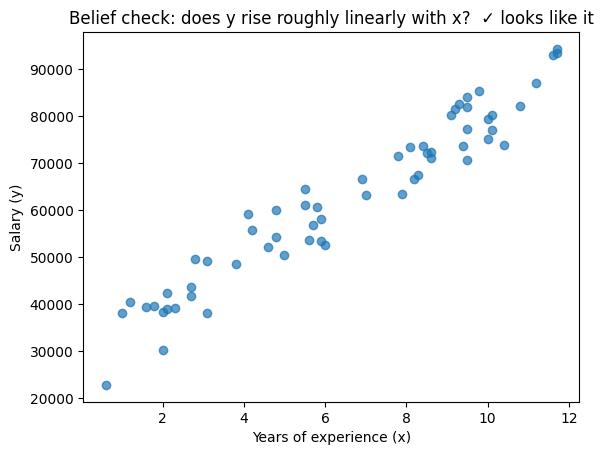

In [2]:
df = pd.read_csv("data/salary_data.csv")
print(df.head(), f"\n\n{len(df)} people")

x = df["years_experience"].values   # feature  (what we HAVE)      — README §0
y = df["salary"].values             # target   (what we PREDICT)   — README §0

plt.scatter(x, y, alpha=0.7)
plt.xlabel("Years of experience (x)"); plt.ylabel("Salary (y)")
plt.title("Belief check: does y rise roughly linearly with x?  ✓ looks like it")
plt.show()

## Block 3 — Feature scaling *(README §4, "the canyon problem")*

Salary is in tens of thousands; experience is in single digits. On such mismatched scales the loss bowl becomes a stretched canyon and gradient descent zigzags or explodes. Standardizing (mean 0, std 1) makes the bowl round. We keep the original means/stds so we can convert predictions back to real units later.

In [3]:
x_mean, x_std = x.mean(), x.std()
y_mean, y_std = y.mean(), y.std()

X = (x - x_mean) / x_std     # standardized feature
Y = (y - y_mean) / y_std     # standardized target

print(f"X: mean={X.mean():.2f}, std={X.std():.2f}   Y: mean={Y.mean():.2f}, std={Y.std():.2f}")

X: mean=0.00, std=1.00   Y: mean=0.00, std=1.00


## Block 4 — The model: one line of code *(README §3.1)*

`ŷ = w·x + b` — the slope **w** says how much y changes per unit of x; the bias **b** shifts the line up/down (README §0). This single line, stacked millions of times with bends between, is a neural network.

In [4]:
def predict(X, w, b):
    """The hypothesis: our guess for every input at once. README §3.1"""
    return w * X + b

## Block 5 — The loss: how wrong are we, as ONE number *(README §3.2)*

Mean Squared Error: (guess − truth)², averaged. Squared so that + and − errors can't cancel, and so big blunders hurt disproportionately (README §2.2).

In [5]:
def mse_loss(Y_pred, Y_true):
    """README §3.2 — the height of the ball on the bowl."""
    return np.mean((Y_pred - Y_true) ** 2)

# Sanity check: an untrained model (w=0, b=0 → flat line at 0) should be very wrong.
print("Loss before any learning:", mse_loss(predict(X, 0.0, 0.0), Y).round(3))
# On standardized data, always guessing the mean gives loss = 1.0. That's our 'clueless' baseline.

Loss before any learning: 1.0


## Block 6 — The gradients: which way is downhill? *(README §3.3)*

Both formulas are driven by `(guess − truth)` — **the model only learns from its mistakes**. The w-gradient weights each mistake by its x (far-out points twist the slope harder); the b-gradient is just the average mistake (too high overall → shift down).

In [6]:
def gradients(X, Y_true, w, b):
    """README §3.3 — derivatives of the loss w.r.t. each knob."""
    error = predict(X, w, b) - Y_true          # (guess − truth), for every point
    dw = np.mean(2 * error * X)                # mistakes with leverage → slope correction
    db = np.mean(2 * error)                    # average mistake     → shift correction
    return dw, db

## Block 7 — The training loop: watch the ball roll *(README §3.4)*

`w ← w − α·gradient`. The **minus sign is the entire algorithm**: gradient points uphill, we step down. This loop IS forward pass + backpropagation — the same loop trains GPT, just with longer gradient formulas.

epoch   0 | loss 0.8227 | w=0.097 b=0.000
epoch  50 | loss 0.0670 | w=0.961 b=-0.000
epoch 100 | loss 0.0670 | w=0.966 b=-0.000
epoch 150 | loss 0.0670 | w=0.966 b=-0.000
epoch 200 | loss 0.0670 | w=0.966 b=-0.000
epoch 250 | loss 0.0670 | w=0.966 b=-0.000
epoch 299 | loss 0.0670 | w=0.966 b=-0.000


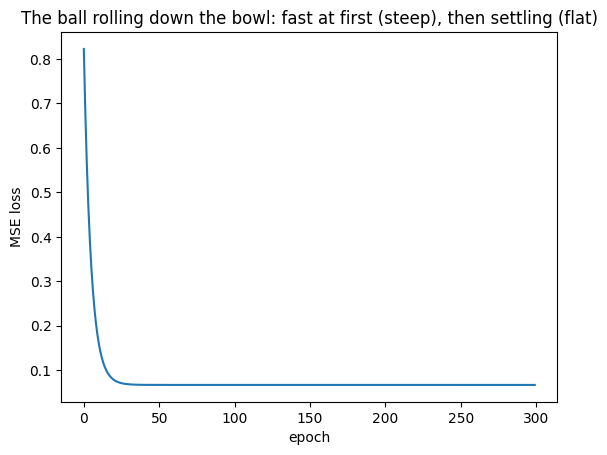

In [7]:
w, b = 0.0, 0.0        # start clueless (README §4: bowl has one bottom, so start anywhere)
lr = 0.05              # learning rate α — step size (README §0, §4)
epochs = 300           # how many downhill steps

history = []
for epoch in range(epochs):
    dw, db = gradients(X, Y, w, b)   # 1. feel the slope        (backward pass)
    w -= lr * dw                     # 2. step downhill in w    (the update)
    b -= lr * db                     # 3. step downhill in b
    history.append(mse_loss(predict(X, w, b), Y))
    if epoch % 50 == 0 or epoch == epochs - 1:
        print(f"epoch {epoch:3d} | loss {history[-1]:.4f} | w={w:.3f} b={b:.3f}")

plt.plot(history)
plt.xlabel("epoch"); plt.ylabel("MSE loss")
plt.title("The ball rolling down the bowl: fast at first (steep), then settling (flat)")
plt.show()

Loss drops steeply, then flattens — nobody programmed "slow down near the answer"; it emerges because the gradient (slope of the bowl) shrinks near the bottom (README §2.3).

Now convert the learned standardized (w, b) back to real units and check against the truth. The data was generated with **true slope 5,200 and intercept 30,000** — did the model discover this purely from mistakes?

Learned:  salary ≈ 5,170 × years + 28,951
Truth  :  salary ≈ 5,200 × years + 30,000  (+ noise)


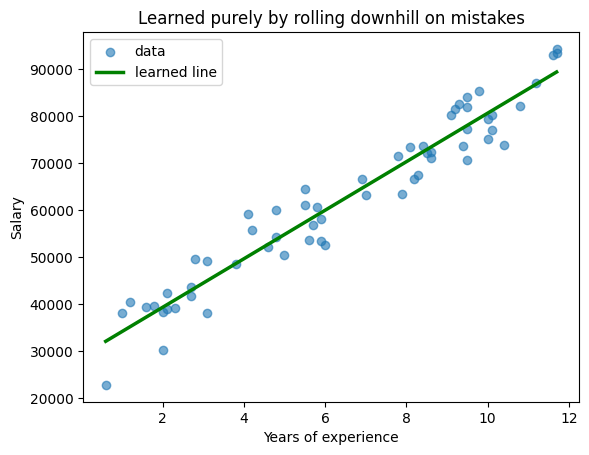

In [8]:
# Undo the standardization algebraically to express the line in real units
w_real = w * (y_std / x_std)
b_real = y_mean + b * y_std - w_real * x_mean
print(f"Learned:  salary ≈ {w_real:,.0f} × years + {b_real:,.0f}")
print( "Truth  :  salary ≈ 5,200 × years + 30,000  (+ noise)")

plt.scatter(x, y, alpha=0.6, label="data")
xs = np.linspace(x.min(), x.max(), 50)
plt.plot(xs, w_real * xs + b_real, color="green", lw=2.5, label="learned line")
plt.xlabel("Years of experience"); plt.ylabel("Salary"); plt.legend()
plt.title("Learned purely by rolling downhill on mistakes")
plt.show()

## Block 8 — Break it on purpose: the learning rate *(README §4)*

The most instructive failure in ML. Same code, three step sizes.

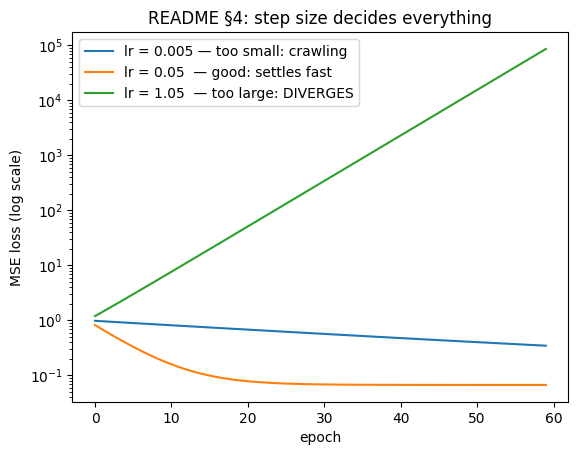

In [9]:
def train(lr, epochs=60):
    w, b, hist = 0.0, 0.0, []
    for _ in range(epochs):
        dw, db = gradients(X, Y, w, b)
        w, b = w - lr * dw, b - lr * db
        hist.append(mse_loss(predict(X, w, b), Y))
    return hist

for lr_, label in [(0.005, "0.005 — too small: crawling"),
                   (0.05,  "0.05  — good: settles fast"),
                   (1.05,  "1.05  — too large: DIVERGES")]:
    plt.plot(train(lr_), label=f"lr = {label}")
plt.yscale("log")   # log scale, otherwise the exploding curve hides the others
plt.xlabel("epoch"); plt.ylabel("MSE loss (log scale)"); plt.legend()
plt.title("README §4: step size decides everything")
plt.show()

## Block 9 — Reading the results *(README §5)*

Training converged — but how good is the model, in words a human cares about? Never one number; each metric answers a different question.

In [10]:
pred_real = w_real * x + b_real            # predictions in real salary units

mse  = np.mean((pred_real - y) ** 2)
rmse = np.sqrt(mse)
mae  = np.mean(np.abs(pred_real - y))
ss_res = np.sum((y - pred_real) ** 2)       # our model's squared errors
ss_tot = np.sum((y - y.mean()) ** 2)        # errors of just guessing the mean
r2 = 1 - ss_res / ss_tot

print(f"MSE  = {mse:,.0f}      ← falls during training; units are salary² (unreadable)")
print(f"RMSE = {rmse:,.0f}     ← 'typically off by ~{rmse:,.0f} in salary' — tell THIS to a stakeholder")
print(f"MAE  = {mae:,.0f}      ← typical miss ignoring outlier drama")
print(f"R²   = {r2:.3f}        ← experience explains ~{r2*100:.0f}% of salary variation")
print(f"\nRMSE vs MAE ratio = {rmse/mae:.2f}  (≫1.3 would hint at a few badly-missed outliers — README §5)")

MSE  = 20,130,083      ← falls during training; units are salary² (unreadable)
RMSE = 4,487     ← 'typically off by ~4,487 in salary' — tell THIS to a stakeholder
MAE  = 3,728      ← typical miss ignoring outlier drama
R²   = 0.933        ← experience explains ~93% of salary variation

RMSE vs MAE ratio = 1.20  (≫1.3 would hint at a few badly-missed outliers — README §5)


## Block 10 — Did the belief hold? Residual check *(README §6)*

The final habit: plot the errors themselves. **Random scatter around zero = the linear belief held.** Any visible pattern (curve, funnel) = the world is bending in a way our straight line cannot.

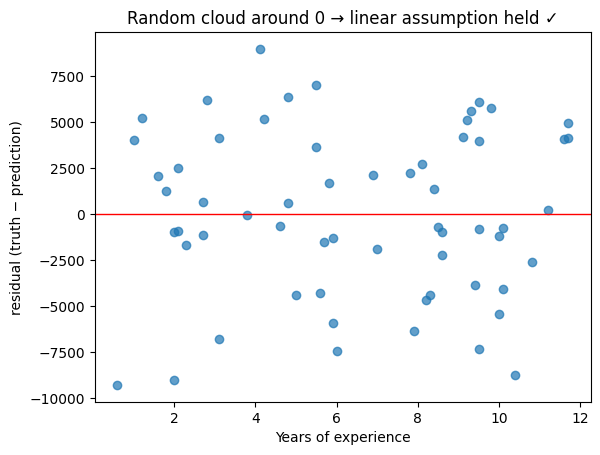

In [11]:
residuals = y - pred_real
plt.scatter(x, residuals, alpha=0.7)
plt.axhline(0, color="red", lw=1)
plt.xlabel("Years of experience"); plt.ylabel("residual (truth − prediction)")
plt.title("Random cloud around 0 → linear assumption held ✓")
plt.show()

---
## What you now own

- The **predict → error → gradient → update** loop — the engine of ALL of deep learning
- Why errors are squared, why the minus sign in the update is the whole algorithm
- What learning rate, bias, and gradient *physically* do — and what breaking each looks like
- How to report results (RMSE for humans, R² for "how much did we explain", residuals for "did the belief hold")

**Next:** `linear_regression_with_library.ipynb` — the same model in 5 lines, verifying our scratch build. Then folder `02-logistic-regression/`: one new idea (squash the line into a probability), same skeleton.